# ***Task 2:- Exploratory Data Analysis***

#### ***Import libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### ***Load dataset***

In [2]:
df = pd.read_csv("smartphones_prepared.csv")
print("Dataset Shape:", df.shape, '\n')
df.head()

Dataset Shape: (2256, 14) 



,model_name,price,expert_rating,user_rating,processor,rear_cameras,front_cameras,display,ram_internal_memory,battery,operating_system,additional_features,review,review_link
0,vivo V40,"34,999",7.8,4.5 ★\n1.3L Ratings,Snapdragon 7 Gen 3 Octa core,50+50 MP Rear Camera,50 MP Front Camera,6.78″ (17.22 cm) 120Hz AMOLED Display,8 GB RAM | 128 GB Storage,5500 mAh | 80W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...
1,OPPO K12x,"12,999",7.8,4.5 ★\n1.3L Ratings,MediaTek Dimensity 6300 Octa core,32+2 MP Rear Camera,8 MP Front Camera,6.67″ (16.94 cm) 120Hz LCD Display,6 GB RAM | 128 GB Storage,5100 mAh | 45W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...
2,vivo V40 Pro,"49,999",8.2,4.5 ★\n1.3L Ratings,MediaTek Dimensity 9200 Plus Octa core,50+50+50 MP Rear Camera,50 MP Front Camera,6.78″ (17.22 cm) 120Hz AMOLED Display,8 GB RAM | 256 GB Storage,5500 mAh | 80W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,"The Vivo V40 Pro shines with its cameras, perf...",https://www.mysmartprice.com/gear/mobiles/mobi...
3,Motorola Edge 50 Fusion,"24,879",8.1,4.5 ★\n16.9K Ratings,Snapdragon 7s Gen 2 Octa core,50+13 MP Rear Camera,32 MP Front Camera,6.67″ (16.94 cm) 144Hz P-OLED Display,8 GB RAM | 128 GB Storage,5000 mAh | 68W Fast Charging,Android v14 OS,5G | NFC | Fingerprint Sensor,Moto Edge 50 Fusion has a premium design and s...,https://www.mysmartprice.com/gear/mobiles/mobi...
4,Samsung Galaxy M35 5G,"19,999",7.8,4.3 ★\n383 Ratings,Samsung Exynos 1380 Octa core,50+8+2 MP Rear Camera,13 MP Front Camera,6.6″ (16.76 cm) 120Hz Super AMOLED Display,6 GB RAM | 128 GB Storage,6000 mAh | 25W Fast Charging,Android v14 OS,5G | NFC | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...


#### ***Understand the dataset***

In [3]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_name           2256 non-null   object 
 1   price                2256 non-null   object 
 2   expert_rating        2256 non-null   float64
 3   user_rating          2256 non-null   object 
 4   processor            2256 non-null   object 
 5   rear_cameras         2256 non-null   object 
 6   front_cameras        2256 non-null   object 
 7   display              2256 non-null   object 
 8   ram_internal_memory  2256 non-null   object 
 9   battery              2256 non-null   object 
 10  operating_system     2256 non-null   object 
 11  additional_features  2256 non-null   object 
 12  review               2256 non-null   object 
 13  review_link          2256 non-null   object 
dtypes: float64(1), object(13)
memory usage: 246.9+ KB


In [4]:
print("Column Names:\n")
print(df.columns.tolist())

Column Names:

['model_name', 'price', 'expert_rating', 'user_rating', 'processor', 'rear_cameras', 'front_cameras', 'display', 'ram_internal_memory', 'battery', 'operating_system', 'additional_features', 'review', 'review_link']


#### ***Check missing values***

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
model_name             0
price                  0
expert_rating          0
user_rating            0
processor              0
rear_cameras           0
front_cameras          0
display                0
ram_internal_memory    0
battery                0
operating_system       0
additional_features    0
review                 0
review_link            0
dtype: int64

Total Missing Values: 0


#### ***Check duplicate rows***

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


#### ***Descriptive statistics***

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
expert_rating,2256.0,7.799911,0.474213,3.5,7.8,7.8,8.0,9.5


### ***Prepare Numerical Features***

#### ***Convert price***

In [8]:
df["price_numeric"] = (
    df["price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price_numeric"] = pd.to_numeric(
    df["price_numeric"],
    errors="coerce"
)

print(df[["price", "price_numeric"]].head(10))

    price  price_numeric
0  34,999          34999
1  12,999          12999
2  49,999          49999
3  24,879          24879
4  19,999          19999
5  24,998          24998
6  18,880          18880
7  29,998          29998
8  29,495          29495
9  27,999          27999


#### ***Convert user rating***

In [9]:
df["user_rating_numeric"] = (
    df["user_rating"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
)

df["user_rating_numeric"] = pd.to_numeric(
    df["user_rating_numeric"],
    errors="coerce"
)

print(df[[
    "user_rating",
    "user_rating_numeric"
]].head(10))

            user_rating  user_rating_numeric
0   4.5 ★\n1.3L Ratings                  4.5
1   4.5 ★\n1.3L Ratings                  4.5
2   4.5 ★\n1.3L Ratings                  4.5
3  4.5 ★\n16.9K Ratings                  4.5
4    4.3 ★\n383 Ratings                  4.3
5  4.2 ★\n3,455 Ratings                  4.2
6   4.5 ★\n1.3L Ratings                  4.5
7   4.5 ★\n1.3L Ratings                  4.5
8  4.4 ★\n17.5K Ratings                  4.4
9  4.5 ★\n4,803 Ratings                  4.5


#### ***Extract RAM and storage***

In [10]:
ram_text = df["ram_internal_memory"].astype(str)

#### ***RAM***

In [11]:
ram_gb = ram_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*GB\s*RAM",
    expand=False
)

ram_mb = ram_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*MB\s*RAM",
    expand=False
)

ram_gb = pd.to_numeric(ram_gb, errors="coerce")
ram_mb = pd.to_numeric(ram_mb, errors="coerce")

df["ram_gb"] = ram_gb

# Convert MB to GB
df.loc[df["ram_gb"].isna(), "ram_gb"] = (
    ram_mb[df["ram_gb"].isna()] / 1024
)


#### ***Storage***

In [12]:
storage_gb = ram_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*GB\s*Storage",
    expand=False
)

storage_tb = ram_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*TB\s*Storage",
    expand=False
)

storage_mb = ram_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*MB\s*Storage",
    expand=False
)

storage_gb = pd.to_numeric(
    storage_gb,
    errors="coerce"
)

storage_tb = pd.to_numeric(
    storage_tb,
    errors="coerce"
)

storage_mb = pd.to_numeric(
    storage_mb,
    errors="coerce"
)

df["storage_gb"] = storage_gb

# Convert TB to GB
df.loc[df["storage_gb"].isna(), "storage_gb"] = (
    storage_tb[df["storage_gb"].isna()] * 1024
)

# Convert MB to GB
df.loc[df["storage_gb"].isna(), "storage_gb"] = (
    storage_mb[df["storage_gb"].isna()] / 1024
)

In [13]:
print("Missing RAM:", df["ram_gb"].isnull().sum())
print("Missing Storage:", df["storage_gb"].isnull().sum())

Missing RAM: 6
Missing Storage: 0


#### ***Verify RAM and storage***

In [14]:
display(df[
        [
            "ram_internal_memory",
            "ram_gb",
            "storage_gb"
        ]
    ].head(30)
)

,ram_internal_memory,ram_gb,storage_gb
0,8 GB RAM | 128 GB Storage,8.0,128.0
1,6 GB RAM | 128 GB Storage,6.0,128.0
2,8 GB RAM | 256 GB Storage,8.0,256.0
3,8 GB RAM | 128 GB Storage,8.0,128.0
4,6 GB RAM | 128 GB Storage,6.0,128.0
5,8 GB RAM | 128 GB Storage,8.0,128.0
6,8 GB RAM | 128 GB Storage,8.0,128.0
7,8 GB RAM | 128 GB Storage,8.0,128.0
8,8 GB RAM | 256 GB Storage,8.0,256.0
9,8 GB RAM | 128 GB Storage,8.0,128.0


#### ***Extract battery capacity***

In [15]:
df["battery_mAh"] = (
    df["battery"]
    .astype(str)
    .str.extract(
        r"(\d{3,5})",
        expand=False
    )
)

df["battery_mAh"] = pd.to_numeric(
    df["battery_mAh"],
    errors="coerce"
)

print(
    "Missing Battery Values:",
    df["battery_mAh"].isnull().sum()
)

Missing Battery Values: 0


#### ***Rear camera***

In [16]:
df["rear_camera_mp"] = (
    df["rear_cameras"]
    .astype(str)
    .str.extract(
        r"(\d+(?:\.\d+)?)\s*MP",
        expand=False
    )
)

df["rear_camera_mp"] = pd.to_numeric(
    df["rear_camera_mp"],
    errors="coerce"
)

print(
    "Missing Rear Camera Values:",
    df["rear_camera_mp"].isnull().sum()
)

Missing Rear Camera Values: 0


#### ***Front camera***

In [17]:
df["front_camera_mp"] = (
    df["front_cameras"]
    .astype(str)
    .str.extract(
        r"(\d+(?:\.\d+)?)\s*MP",
        expand=False
    )
)

df["front_camera_mp"] = pd.to_numeric(
    df["front_camera_mp"],
    errors="coerce"
)

print(
    "Missing Front Camera Values:",
    df["front_camera_mp"].isnull().sum()
)

Missing Front Camera Values: 0


#### ***Extract display size***

In [18]:
df["display_size"] = (
    df["display"]
    .astype(str)
    .str.extract(
        r"(\d+(?:\.\d+)?)\s*″",
        expand=False
    )
)

df["display_size"] = pd.to_numeric(
    df["display_size"],
    errors="coerce"
)

print(
    "Missing Display Size Values:",
    df["display_size"].isnull().sum()
)

Missing Display Size Values: 1


#### ***Price Distribution***

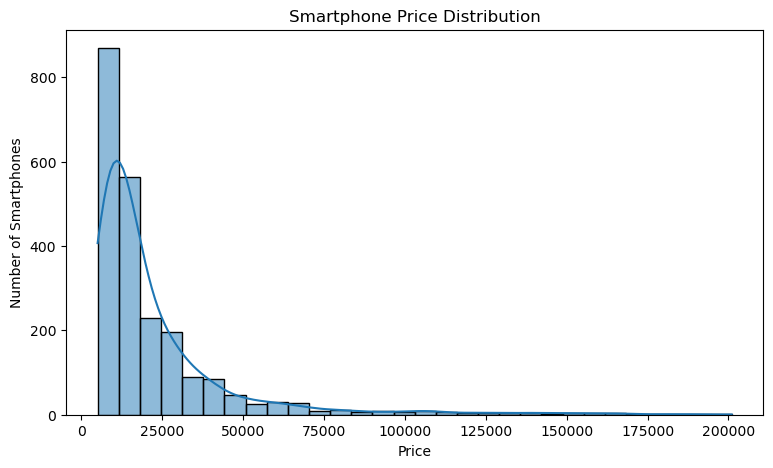

In [19]:
plt.figure(figsize = (9, 5))
sns.histplot(data = df, x = "price_numeric", bins = 30, kde = True)
plt.title("Smartphone Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Smartphones")
plt.show()

#### ***Price boxplot***

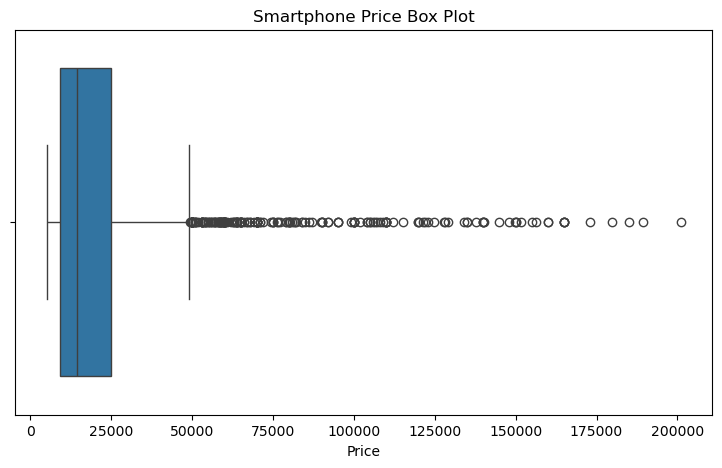

In [20]:
plt.figure(figsize = (9, 5))
sns.boxplot(data = df, x = "price_numeric")
plt.title("Smartphone Price Box Plot")
plt.xlabel("Price")
plt.show()

#### ***Expert Rating Distribution***

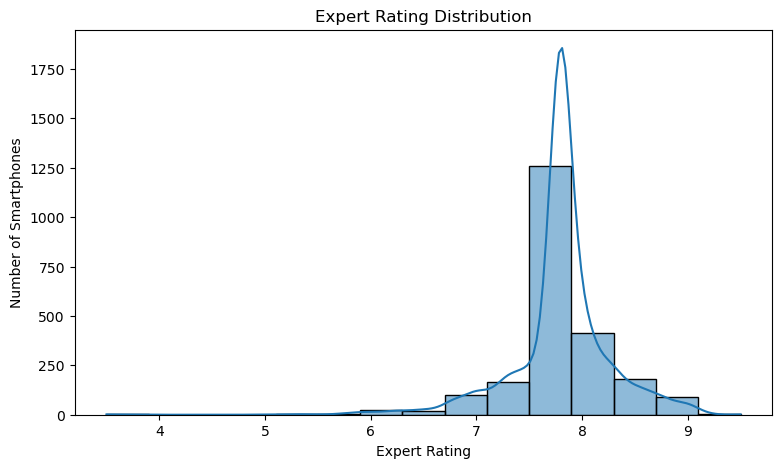

In [21]:
plt.figure(figsize = (9, 5))
sns.histplot(data = df, x = "expert_rating", bins = 15, kde = True)
plt.title("Expert Rating Distribution")
plt.xlabel("Expert Rating")
plt.ylabel("Number of Smartphones")
plt.show()

#### ***Expert Rating Boxplot***

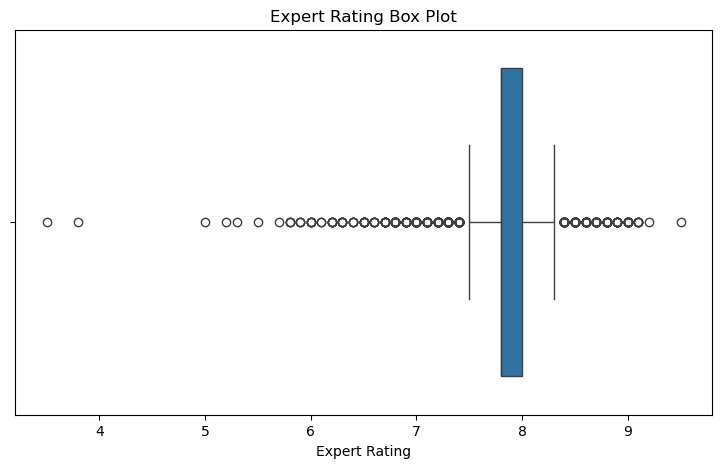

In [22]:
plt.figure(figsize = (9, 5))
sns.boxplot(data = df, x = "expert_rating")
plt.title("Expert Rating Box Plot")
plt.xlabel("Expert Rating")
plt.show()

#### ***User Rating Distribution***

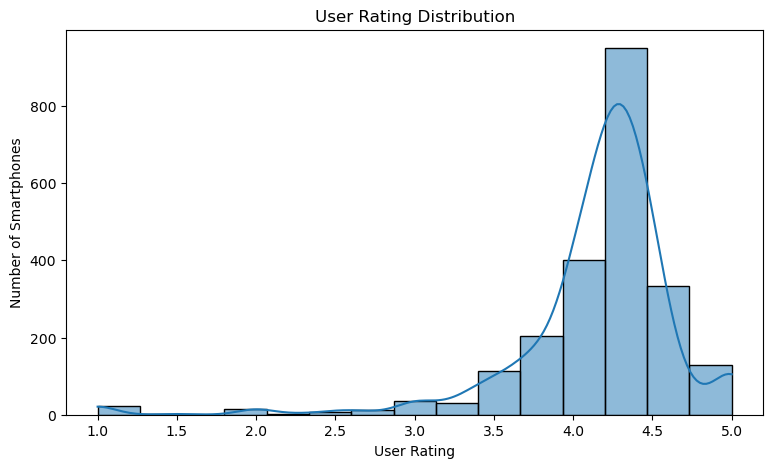

In [23]:
plt.figure(figsize = (9, 5))
sns.histplot(data = df, x = "user_rating_numeric", bins = 15, kde = True)
plt.title("User Rating Distribution")
plt.xlabel("User Rating")
plt.ylabel("Number of Smartphones")
plt.show()

#### ***RAM Distribution***

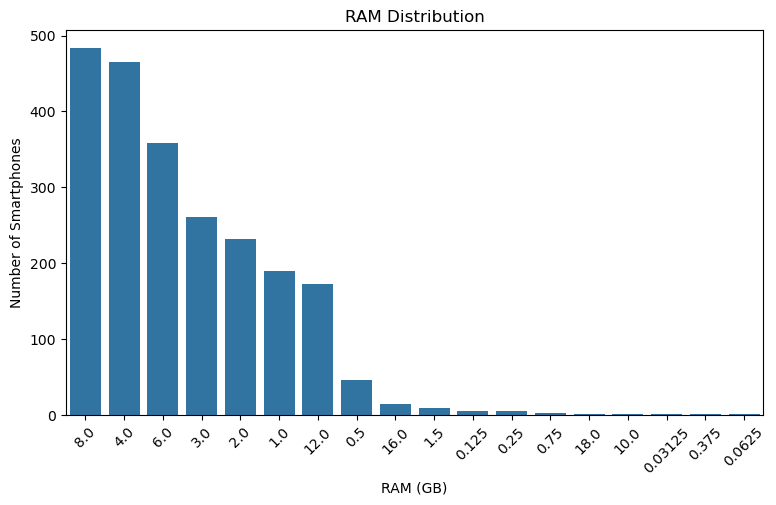

In [24]:
plt.figure(figsize = (9, 5))
sns.countplot(data = df, x = "ram_gb",order = df["ram_gb"].value_counts().index)
plt.title("RAM Distribution")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Smartphones")
plt.xticks(rotation = 45)
plt.show()

#### ***Storage Distribution***

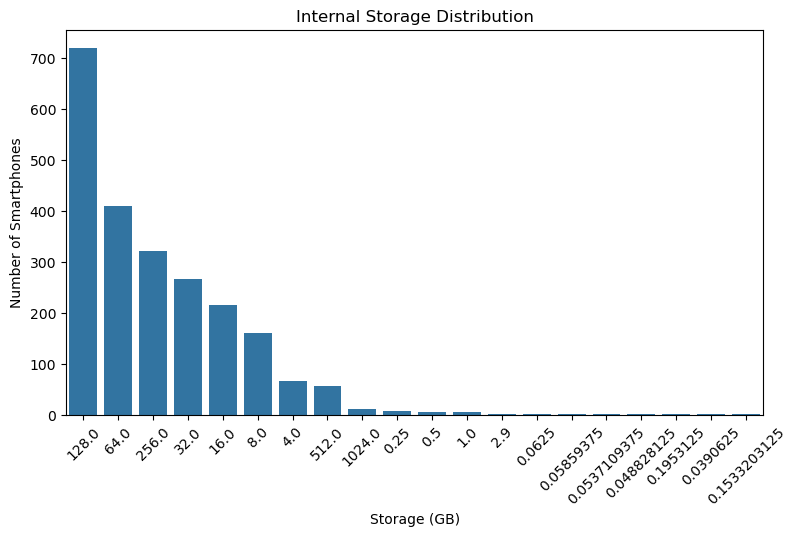

In [25]:
plt.figure(figsize = (9, 5))

sns.countplot(data = df, x = "storage_gb", order = df["storage_gb"].value_counts().index)
plt.title("Internal Storage Distribution")
plt.xlabel("Storage (GB)")
plt.ylabel("Number of Smartphones")
plt.xticks(rotation = 45)
plt.show()

#### ***Battery Distribution***

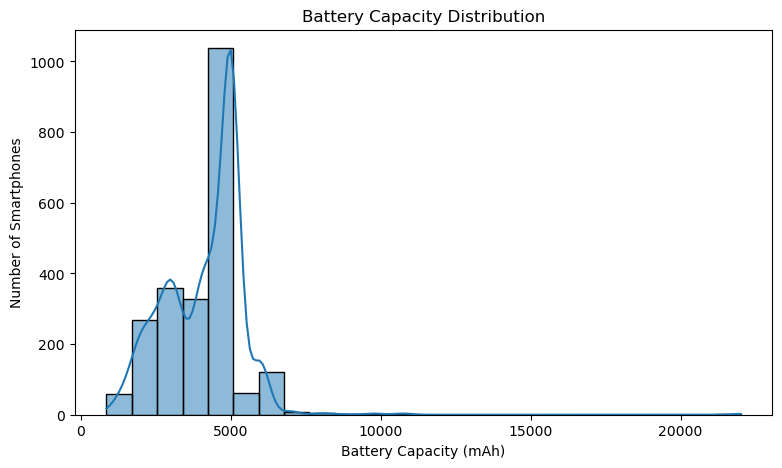

In [26]:
plt.figure(figsize = (9, 5))

sns.histplot(data = df, x = "battery_mAh", bins = 25, kde = True)
plt.title("Battery Capacity Distribution")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Number of Smartphones")
plt.show()

#### ***Rear Camera Distribution***

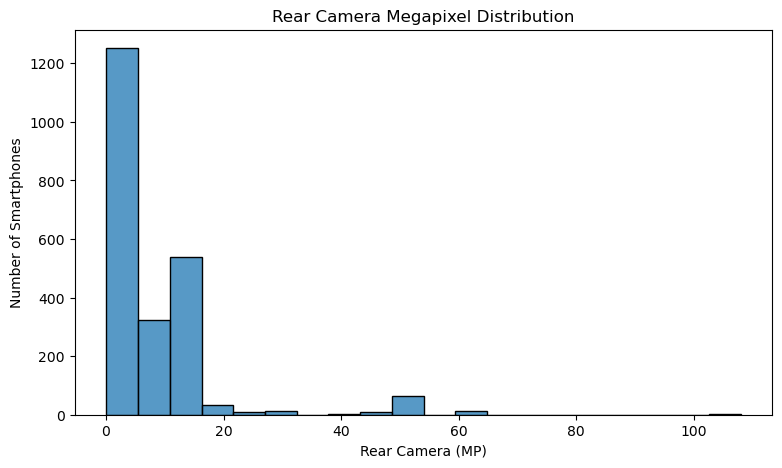

In [27]:
plt.figure(figsize = (9, 5))
sns.histplot(data = df, x = "rear_camera_mp", bins = 20)
plt.title("Rear Camera Megapixel Distribution")
plt.xlabel("Rear Camera (MP)")
plt.ylabel("Number of Smartphones")
plt.show()

#### ***Front Camera Distribution***

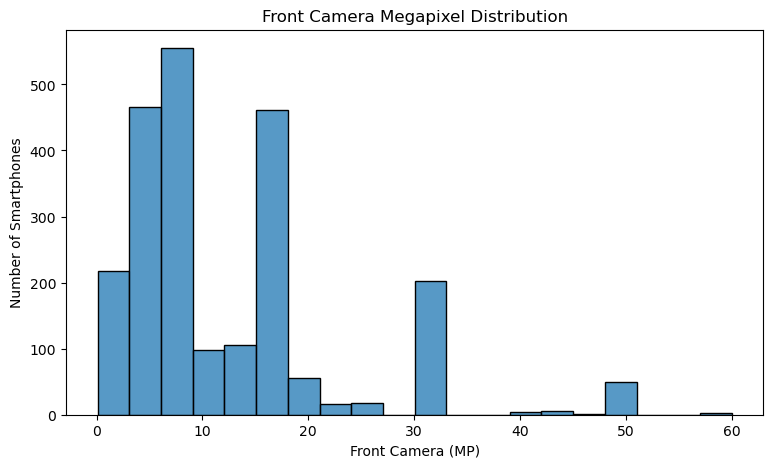

In [28]:
plt.figure(figsize = (9, 5))
sns.histplot(data = df, x = "front_camera_mp", bins = 20)
plt.title("Front Camera Megapixel Distribution")
plt.xlabel("Front Camera (MP)")
plt.ylabel("Number of Smartphones")
plt.show()

#### ***Display Distribution***

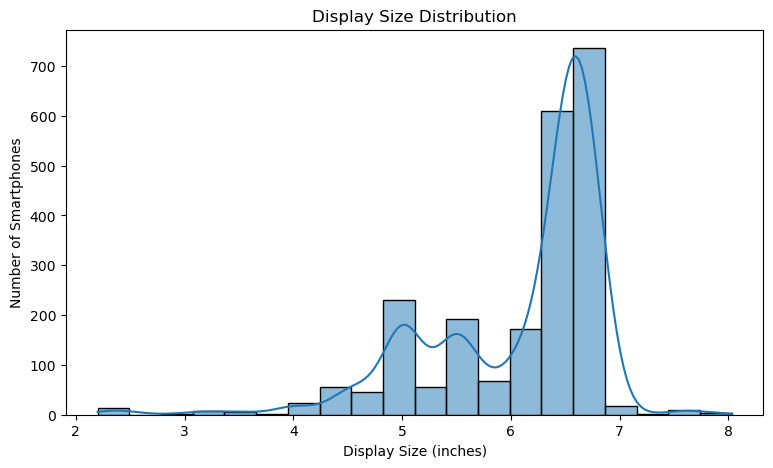

In [29]:
plt.figure(figsize = (9, 5))
sns.histplot(data = df, x = "display_size", bins = 20, kde = True)
plt.title("Display Size Distribution")
plt.xlabel("Display Size (inches)")
plt.ylabel("Number of Smartphones")
plt.show()

#### ***Operating System Distribution***

In [30]:
os_counts = df["operating_system"].value_counts()
print(os_counts)

operating_system
Android v11 OS           303
Android v13 OS           290
Android v12 OS           238
Android v10 OS           211
Android v14 OS           210
                        ... 
Android v4.0.4 OS          1
Blackberry v10.2 OS        1
Blackberry v10.3.1 OS      1
Pragati OS OS              1
Sailfish OS v2.0 OS        1
Name: count, Length: 69, dtype: int64


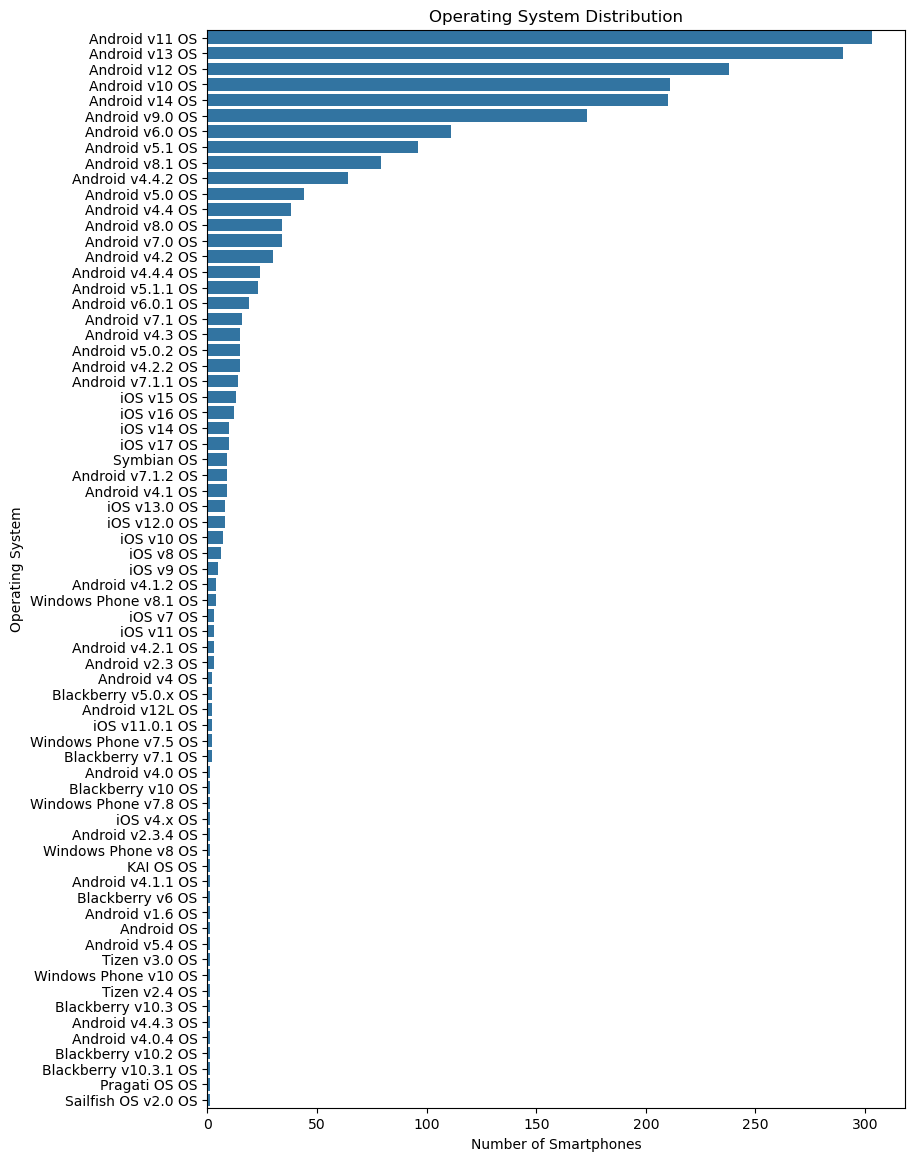

In [31]:
plt.figure(figsize = (9, 14))
sns.barplot(x = os_counts.values, y = os_counts.index)
plt.title("Operating System Distribution")
plt.xlabel("Number of Smartphones")
plt.ylabel("Operating System")
plt.show()

#### ***Processor Distribution***

In [32]:
processor_counts = (df["processor"].value_counts().head(15))
print(processor_counts)

processor
Unisoc Octa core                          129
MediaTek                                   83
MediaTek Quad core                         79
MediaTek Tru-Octa Core                     70
MediaTek Helio G85 Octa core               51
Samsung Exynos 9 Octa Octa core            47
Snapdragon 695 Octa core                   42
Snapdragon 680 Octa core                   37
MediaTek Helio P22 Tru-Octa Core           33
MediaTek Octa core                         33
Spreadtrum Quad core                       26
MediaTek Dimensity 6100 Plus Octa core     26
MediaTek Dimensity 7050 Octa core          26
Snapdragon 888 Octa core                   25
Snapdragon 778G Octa core                  24
Name: count, dtype: int64


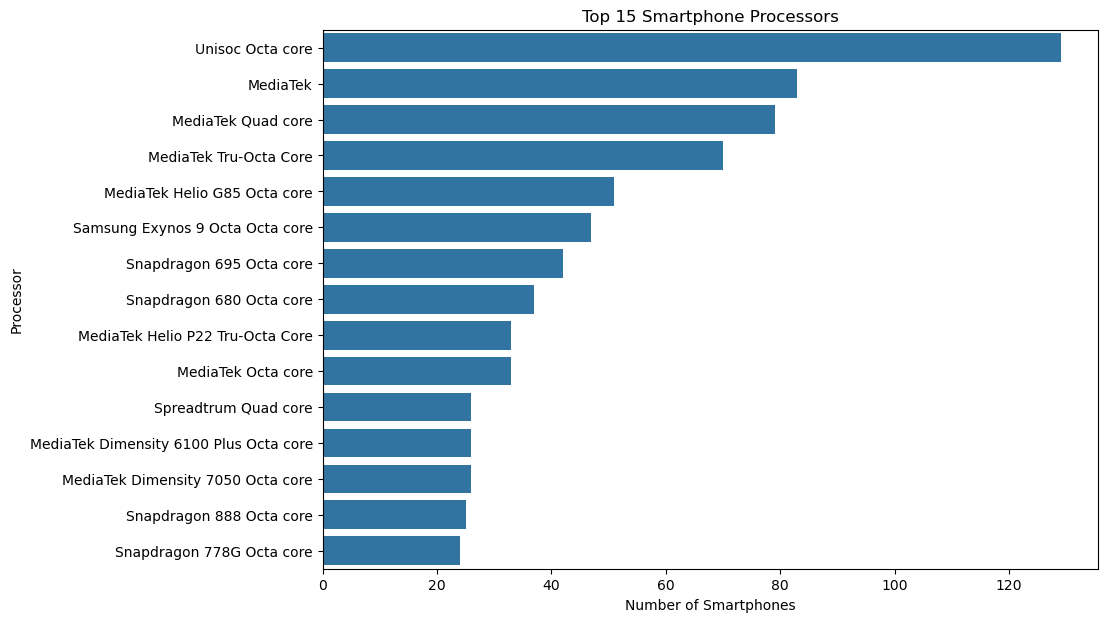

In [33]:
plt.figure(figsize = (10, 7))
sns.barplot(x = processor_counts.values, y = processor_counts.index)
plt.title("Top 15 Smartphone Processors")
plt.xlabel("Number of Smartphones")
plt.ylabel("Processor")
plt.show()

#### ***Brand Analysis***

In [34]:
df["brand"] = (
    df["model_name"]
    .astype(str)
    .str.split()
    .str[0]
)

print(df[["model_name", "brand"]].head(20))

                   model_name     brand
0                    vivo V40      vivo
1                   OPPO K12x      OPPO
2                vivo V40 Pro      vivo
3     Motorola Edge 50 Fusion  Motorola
4       Samsung Galaxy M35 5G   Samsung
5        OnePlus Nord CE 4 5G   OnePlus
6                    Moto G85      Moto
7              OnePlus Nord 4   OnePlus
8     Motorola Edge 50 Pro 5G  Motorola
9                    vivo V30      vivo
10           Motorola Edge 50  Motorola
11                   Moto G64      Moto
12                CMF Phone 1       CMF
13         realme 13 Pro Plus    realme
14                OnePlus 12R   OnePlus
15       Xiaomi Redmi Note 13    Xiaomi
16          OPPO F27 Pro Plus      OPPO
17   Samsung Galaxy S24 Ultra   Samsung
18  OnePlus Nord CE 4 Lite 5G   OnePlus
19      Samsung Galaxy A35 5G   Samsung


#### ***Top brands***

In [35]:
brand_counts = df["brand"].value_counts()
print("Top 15 Brands:")
print(brand_counts.head(15))

Top 15 Brands:
brand
Samsung     312
realme      210
vivo        195
Xiaomi      194
OPPO        130
Apple        88
OnePlus      71
POCO         71
Infinix      65
Lava         64
Moto         62
Tecno        61
Nokia        58
Micromax     57
iQOO         51
Name: count, dtype: int64


#### ***Brand graph***

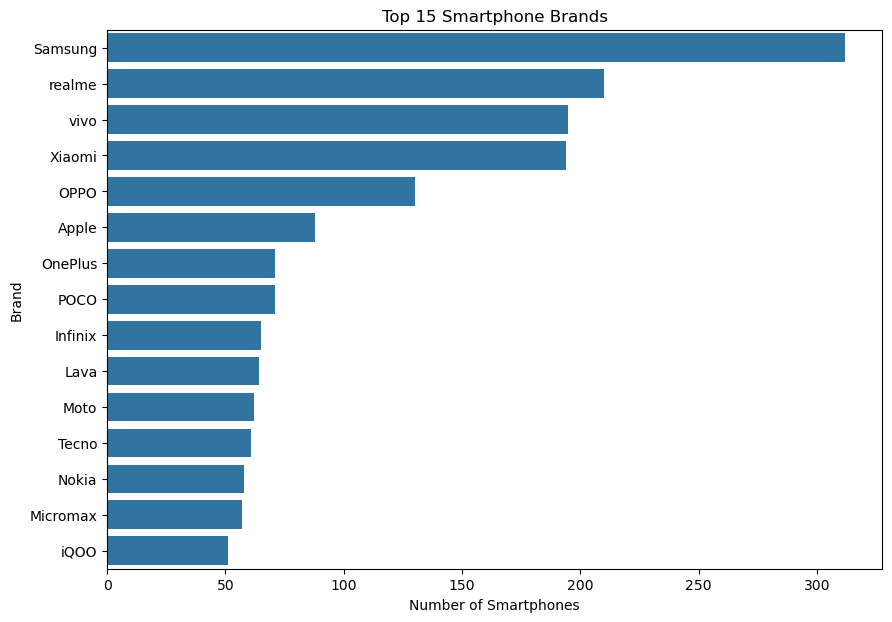

In [36]:
top_brands = brand_counts.head(15)
plt.figure(figsize = (10, 7))
sns.barplot(x = top_brands.values, y = top_brands.index)
plt.title("Top 15 Smartphone Brands")
plt.xlabel("Number of Smartphones")
plt.ylabel("Brand")
plt.show()

#### ***Expert Rating vs Price***

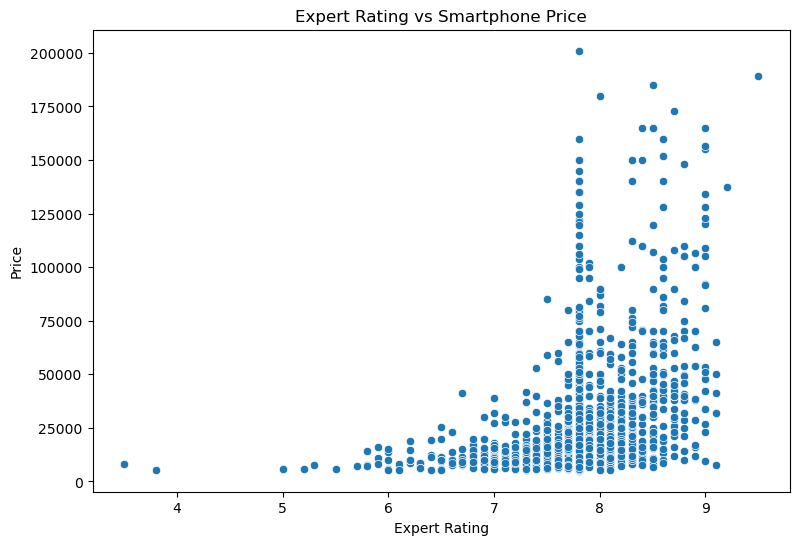

In [37]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = df, x = "expert_rating", y = "price_numeric")
plt.title("Expert Rating vs Smartphone Price")
plt.xlabel("Expert Rating")
plt.ylabel("Price")
plt.show()

#### ***User Rating vs Price***

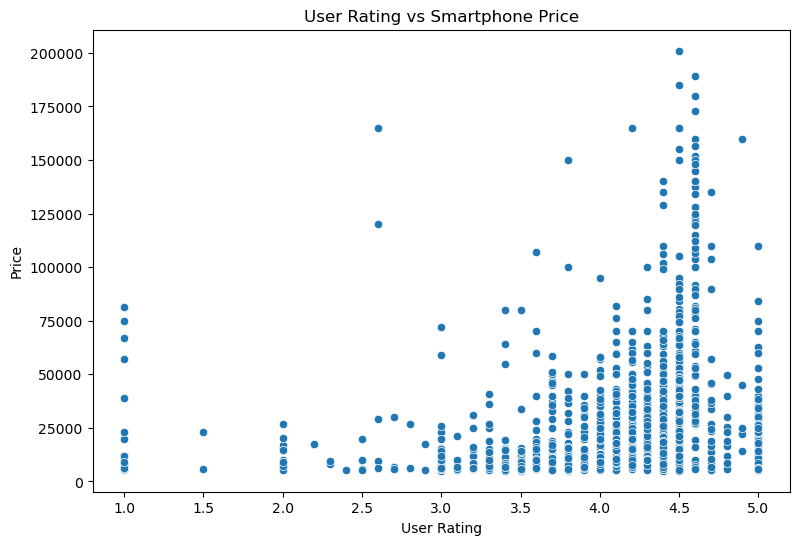

In [38]:
plt.figure(figsize = (9, 6))

sns.scatterplot(data = df, x = "user_rating_numeric", y = "price_numeric")
plt.title("User Rating vs Smartphone Price")
plt.xlabel("User Rating")
plt.ylabel("Price")
plt.show()

#### ***RAM vs Price***

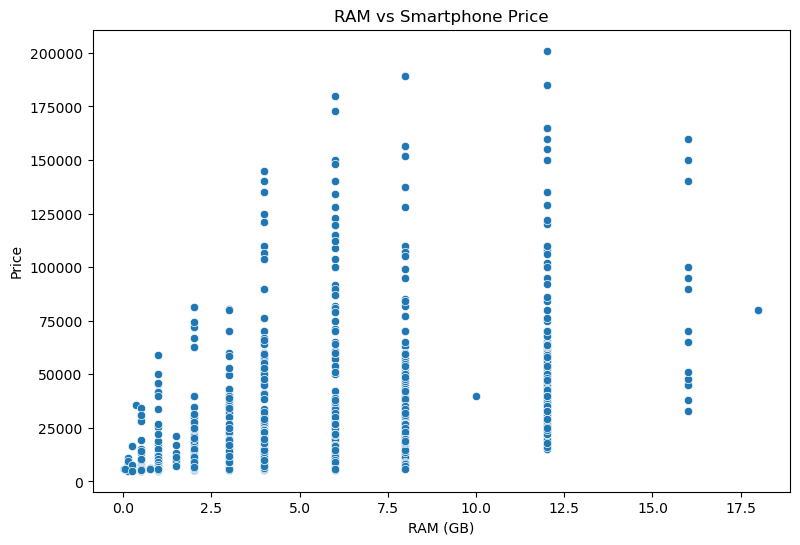

In [39]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = df, x = "ram_gb", y = "price_numeric")
plt.title("RAM vs Smartphone Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.show()

#### ***Storage vs Price***

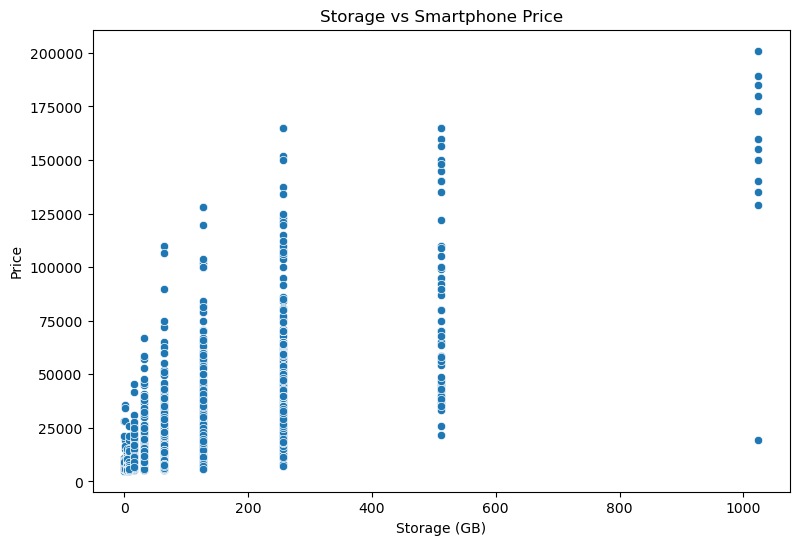

In [40]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = df, x = "storage_gb", y = "price_numeric")
plt.title("Storage vs Smartphone Price")
plt.xlabel("Storage (GB)")
plt.ylabel("Price")
plt.show()

#### ***Battery vs Price***

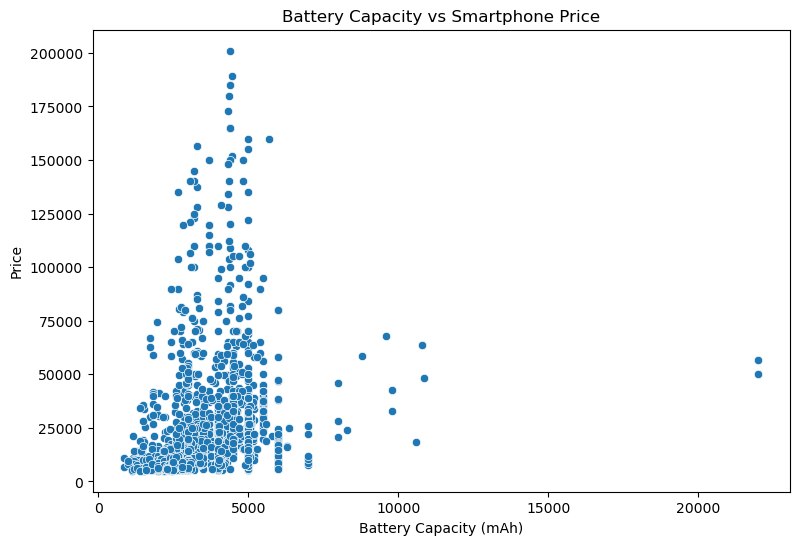

In [41]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = df, x = "battery_mAh", y = "price_numeric")
plt.title("Battery Capacity vs Smartphone Price")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Price")
plt.show()

#### ***Display vs Price***

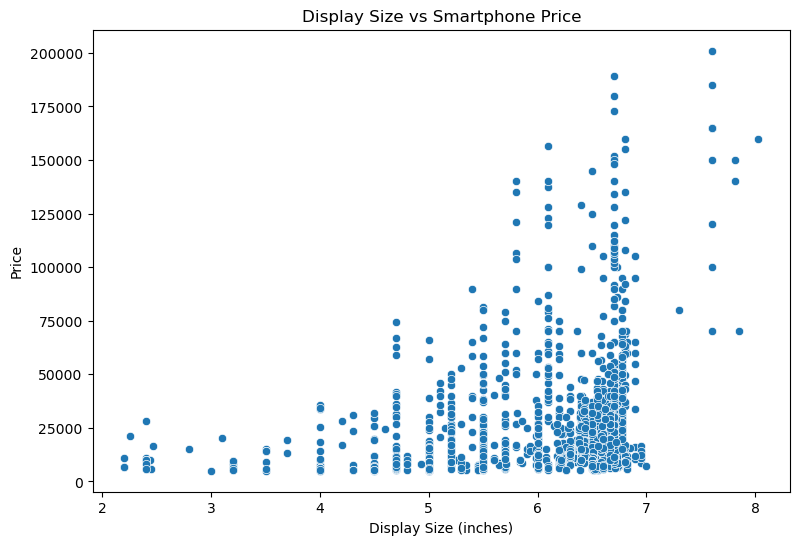

In [42]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = df, x = "display_size", y = "price_numeric")
plt.title("Display Size vs Smartphone Price")
plt.xlabel("Display Size (inches)")
plt.ylabel("Price")
plt.show()

#### ***RAM vs Storage***

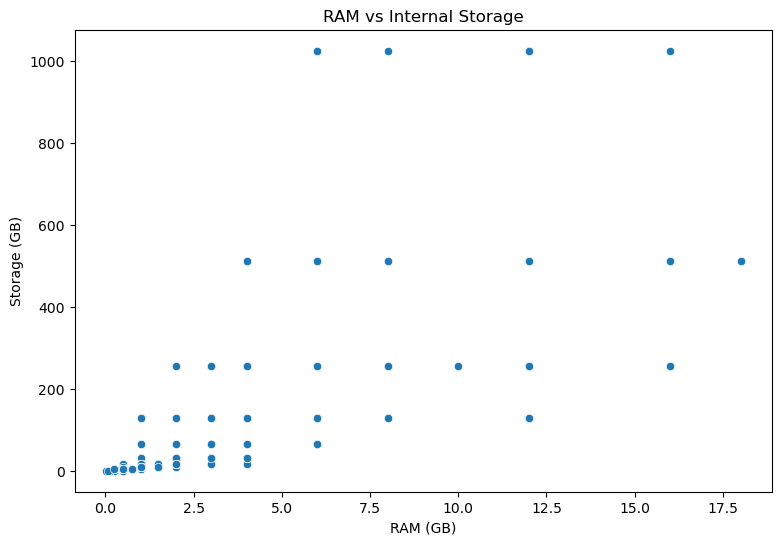

In [43]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = df, x = "ram_gb", y = "storage_gb")
plt.title("RAM vs Internal Storage")
plt.xlabel("RAM (GB)")
plt.ylabel("Storage (GB)")
plt.show()

#### ***Brand vs Price***

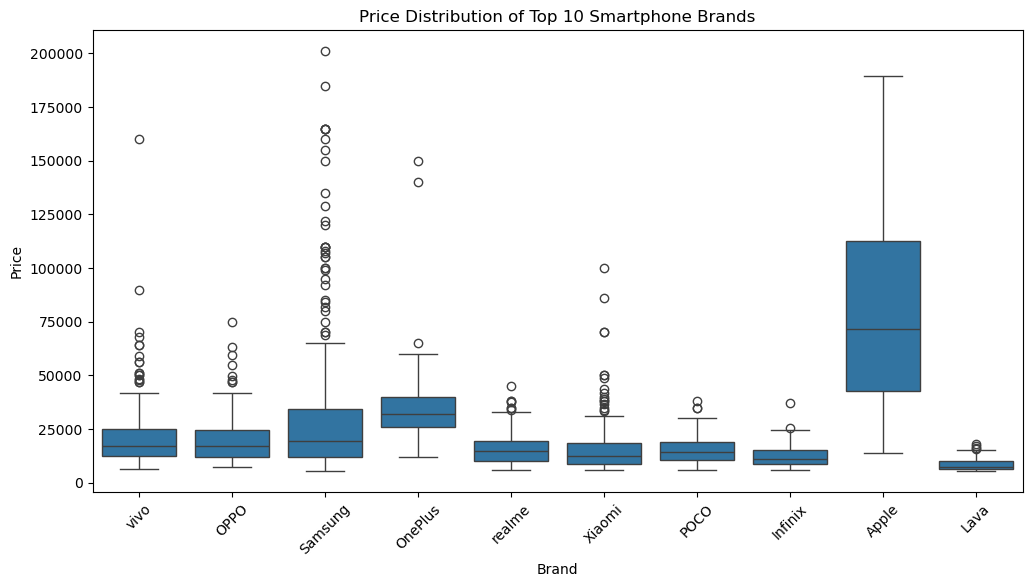

In [44]:
top_10_brands = (df["brand"].value_counts().head(10).index)
brand_data = df[df["brand"].isin(top_10_brands)].copy()

plt.figure(figsize = (12, 6))
sns.boxplot(data = brand_data, x = "brand", y = "price_numeric")
plt.title("Price Distribution of Top 10 Smartphone Brands")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.xticks(rotation = 45)
plt.show()

#### ***Average brand price***

In [45]:
average_brand_price = (brand_data.groupby("brand")["price_numeric"].mean().sort_values(ascending = False))
print(average_brand_price)

brand
Apple      81149.750000
OnePlus    36624.633803
Samsung    31831.487179
vivo       21983.379487
OPPO       20270.961538
Xiaomi     16613.484536
realme     16153.814286
POCO       15824.309859
Infinix    12594.830769
Lava        8595.421875
Name: price_numeric, dtype: float64


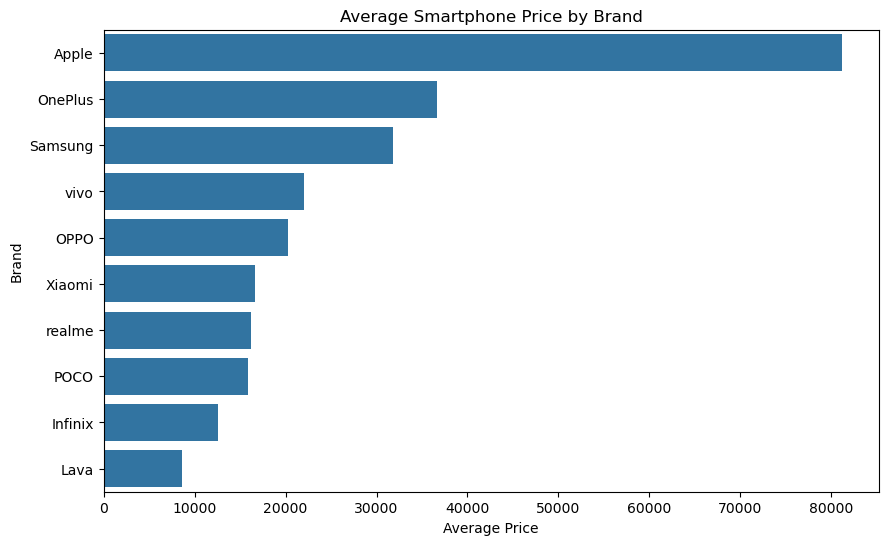

In [46]:
plt.figure(figsize = (10, 6))
sns.barplot(x = average_brand_price.values, y = average_brand_price.index)
plt.title("Average Smartphone Price by Brand")
plt.xlabel("Average Price")
plt.ylabel("Brand")
plt.show()

#### ***Correlation Analysis***

In [47]:
correlation_features = [
    "price_numeric",
    "expert_rating",
    "user_rating_numeric",
    "ram_gb",
    "storage_gb",
    "battery_mAh",
    "rear_camera_mp",
    "front_camera_mp",
    "display_size"
]

correlation = df[correlation_features].corr()
display(correlation)

,price_numeric,expert_rating,user_rating_numeric,ram_gb,storage_gb,battery_mAh,rear_camera_mp,front_camera_mp,display_size
price_numeric,1.000000,0.376202,0.180582,0.484190,0.698308,0.077614,0.288650,0.238066,0.246704
expert_rating,0.376202,1.000000,0.156396,0.306910,0.273826,0.068702,0.086006,0.206979,0.156315
user_rating_numeric,0.180582,0.156396,1.000000,0.233151,0.206680,0.179918,0.055033,0.183386,0.272421
ram_gb,0.484190,0.306910,0.233151,1.000000,0.739286,0.553950,0.161404,0.637717,0.680843
storage_gb,0.698308,0.273826,0.206680,0.739286,1.000000,0.369871,0.200043,0.471295,0.503456
battery_mAh,0.077614,0.068702,0.179918,0.553950,0.369871,1.000000,-0.029706,0.384941,0.769786
rear_camera_mp,0.288650,0.086006,0.055033,0.161404,0.200043,-0.029706,1.000000,0.141648,-0.019517
front_camera_mp,0.238066,0.206979,0.183386,0.637717,0.471295,0.384941,0.141648,1.000000,0.471313
display_size,0.246704,0.156315,0.272421,0.680843,0.503456,0.769786,-0.019517,0.471313,1.000000


#### ***Correlation heatmap***

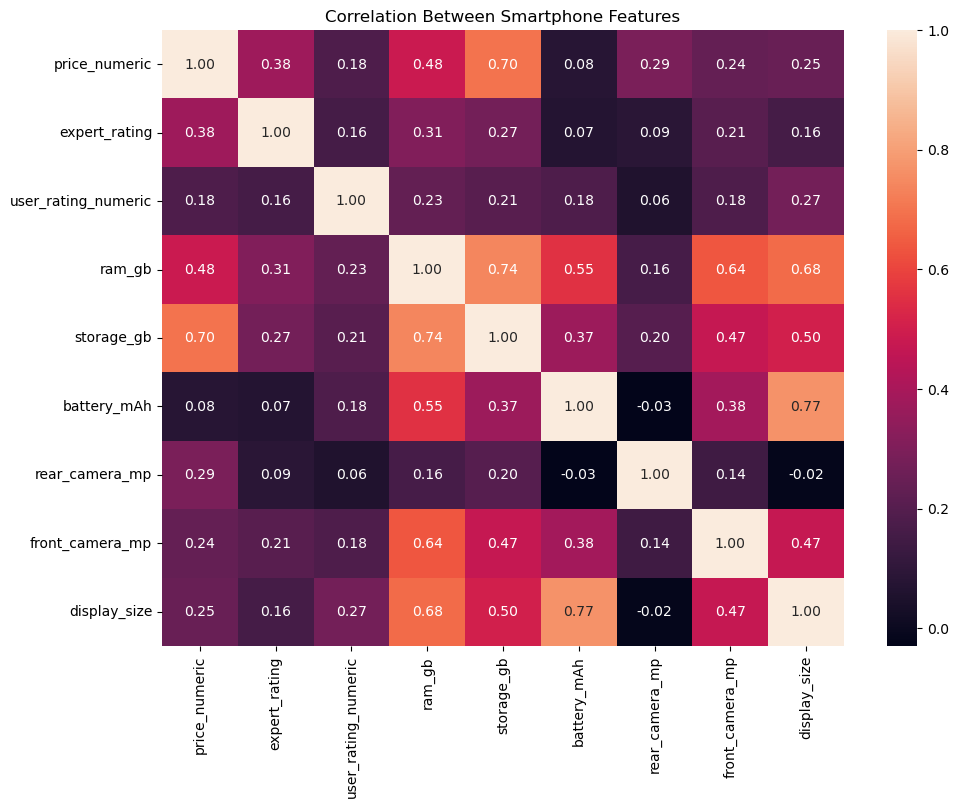

In [48]:
plt.figure(figsize = (11, 8))
sns.heatmap(correlation, annot = True, fmt = ".2f")
plt.title("Correlation Between Smartphone Features")
plt.show()

### ***Top Smartphones***

#### ***Most expensive***

In [49]:
top_expensive = df.nlargest(10, "price_numeric")
display(top_expensive[
        ["model_name", "price_numeric", "expert_rating",
         "user_rating_numeric", "ram_gb", "storage_gb"
        ]
    ]
)

,model_name,price_numeric,expert_rating,user_rating_numeric,ram_gb,storage_gb
617,Samsung Galaxy Z Fold6 5G 1TB,200999,7.8,4.5,12.0,1024.0
582,Apple iPhone 15 Pro Max 1TB,189400,9.5,4.6,8.0,1024.0
1495,Samsung Galaxy Z Fold5 1TB,184999,8.5,4.5,12.0,1024.0
929,Apple iPhone 13 Pro Max 1TB,179900,8.0,4.6,6.0,1024.0
868,Apple iPhone 14 Pro Max 1TB,172990,8.7,4.6,6.0,1024.0
85,Samsung Galaxy Z Fold6,164999,8.5,4.2,12.0,256.0
328,Samsung Galaxy Z Fold5,164999,8.4,4.5,12.0,256.0
1106,Samsung Galaxy Z Fold5 512GB,164999,8.5,4.5,12.0,512.0
1449,Samsung Galaxy Z Fold 4 5G 512GB,164999,9.0,2.6,12.0,512.0
120,vivo X Fold 3 Pro,159999,8.6,4.9,16.0,512.0


#### ***Highest RAM***

In [50]:
top_ram = df.nlargest(10, "ram_gb")
display(top_ram[["model_name", "ram_gb", "storage_gb", "price_numeric"]])

,model_name,ram_gb,storage_gb,price_numeric
1341,Asus ROG Phone 5 Ultimate,18.0,512.0,79999
1370,Asus ROG Phone 5s Pro 5G,18.0,512.0,79999
82,vivo X100 Pro 5G,16.0,512.0,89999
96,Xiaomi 14 Ultra,16.0,512.0,99999
120,vivo X Fold 3 Pro,16.0,512.0,159999
176,OnePlus Open,16.0,512.0,139998
185,Asus ROG Phone 8 Pro,16.0,512.0,94999
222,OnePlus 11R 256GB,16.0,256.0,37990
229,OnePlus 12R 256GB,16.0,256.0,44999
301,OnePlus 12 512GB,16.0,512.0,64999


#### ***Highest battery***

In [51]:
top_battery = df.nlargest(10, "battery_mAh")
display(top_battery[["model_name", "battery_mAh", "price_numeric"]])

,model_name,battery_mAh,price_numeric
424,Doogee V Max,22000,56850
1519,Ulefone Armor 24,22000,50000
1816,Ulefone Armor 20WT,10850,48500
1520,Doogee V31 GT,10800,63500
871,Oukitel WP23,10600,18400
1511,Oukitel WP21 Ultra,9800,42542
1798,Oukitel WP21,9800,33102
698,Ulefone Power Armor 18T Ultra,9600,68000
1522,Blackview BL9000,8800,58500
1753,Oukitel WP17,8300,23966


#### ***Highest expert rating***

In [52]:
top_expert = df.nlargest(10, "expert_rating")
display(top_expert[["model_name","expert_rating","user_rating_numeric","price_numeric"]])

,model_name,expert_rating,user_rating_numeric,price_numeric
582,Apple iPhone 15 Pro Max 1TB,9.5,4.6,189400
786,Apple iPhone 15 Pro 256GB,9.2,4.6,137600
133,Apple iPhone 12,9.1,4.6,41499
197,Google Pixel 7 Pro 5G,9.1,4.2,64999
900,Huawei Mate 20 Pro,9.1,4.4,31999
1149,Sony Xperia XZ,9.1,4.2,49990
1207,Asus Zenfone Max Pro M1,9.1,4.8,7499
256,Apple iPhone 14 Pro Max,9.0,4.6,127999
357,Samsung Galaxy Z Fold 4 5G,9.0,2.6,119999
367,Samsung Galaxy S23 5G 256GB,9.0,4.5,53340


#### ***Final EDA Summary***

In [53]:
print("========== FINAL EDA SUMMARY ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nPrice Statistics:")
print(df["price_numeric"].describe())

print("\nExpert Rating Statistics:")
print(df["expert_rating"].describe())

print("\nUser Rating Statistics:")
print(df["user_rating_numeric"].describe())

print("\nRAM Statistics:")
print(df["ram_gb"].describe())

print("\nStorage Statistics:")
print(df["storage_gb"].describe())

print("\nBattery Statistics:")
print(df["battery_mAh"].describe())

print("\nTop 10 Brands:")
print(df["brand"].value_counts().head(10))

print("\nOperating Systems:")
print(df["operating_system"].value_counts())

========== FINAL EDA SUMMARY ==========

Dataset Shape:
(2256, 23)

Total Missing Values:
7

Duplicate Rows:
0

Price Statistics:
count      2256.000000
mean      22210.675089
std       23948.433554
min        5000.000000
25%        8999.000000
50%       14499.000000
75%       25049.750000
max      200999.000000
Name: price_numeric, dtype: float64

Expert Rating Statistics:
count    2256.000000
mean        7.799911
std         0.474213
min         3.500000
25%         7.800000
50%         7.800000
75%         8.000000
max         9.500000
Name: expert_rating, dtype: float64

User Rating Statistics:
count    2256.000000
mean        4.141312
std         0.549012
min         1.000000
25%         4.000000
50%         4.200000
75%         4.400000
max         5.000000
Name: user_rating_numeric, dtype: float64

RAM Statistics:
count    2250.000000
mean        5.198264
std         3.210808
min         0.031250
25%         3.000000
50%         4.000000
75%         8.000000
max        18.000000